In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
import astropy.constants as const
from astropy.modeling import models, fitting
import lightkurve as lk
from scipy.interpolate import interp1d


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

/home/david/micromamba/envs/stenv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Looking at the longest period wd+ms PCEBS with TESS to see if their RV and photometric periods match. 

In [9]:
wdmscat = Table.read('misc/raw_wdss_data.csv', format='ascii.basic')
wdmscat.dtype.names

('iau_name',
 'type',
 'Teffwd',
 'Teffwde',
 'logg',
 'logge',
 'Mwd',
 'Mwde',
 'Rwd',
 'Rwde',
 'dwd',
 'dwde',
 'Sp',
 'M2',
 'M2e',
 'R2',
 'R2e',
 'Teffsec',
 'Msec',
 'Msece',
 'Rsec',
 'Rsece',
 'Lsec',
 'Lsece',
 'dsec',
 'dsece',
 'age',
 'sigma',
 'porb',
 'porbe',
 'phot',
 'spec',
 're',
 'segue',
 'id',
 'iau_name_1',
 'ra',
 'decl',
 'nuv',
 'nuve',
 'fuv',
 'fuve',
 'u',
 'ue',
 'g',
 'ge',
 'r',
 're_1',
 'i',
 'ie',
 'z',
 'ze',
 'Y',
 'Ye',
 'J',
 'Je',
 'H',
 'He',
 'K',
 'Ke',
 'id_1')

In [12]:
len(wdmscat[wdmscat['porb'] > 0])

63

/tmp/ipykernel_41460/3057179662.py:1: RuntimeWarning: invalid value encountered in divide
  mask = (wdmscat['porb'] > 0) & (wdmscat['Mwd']/wdmscat['Mwde'] > 10) & (wdmscat['M2']/wdmscat['M2e'] > 2)


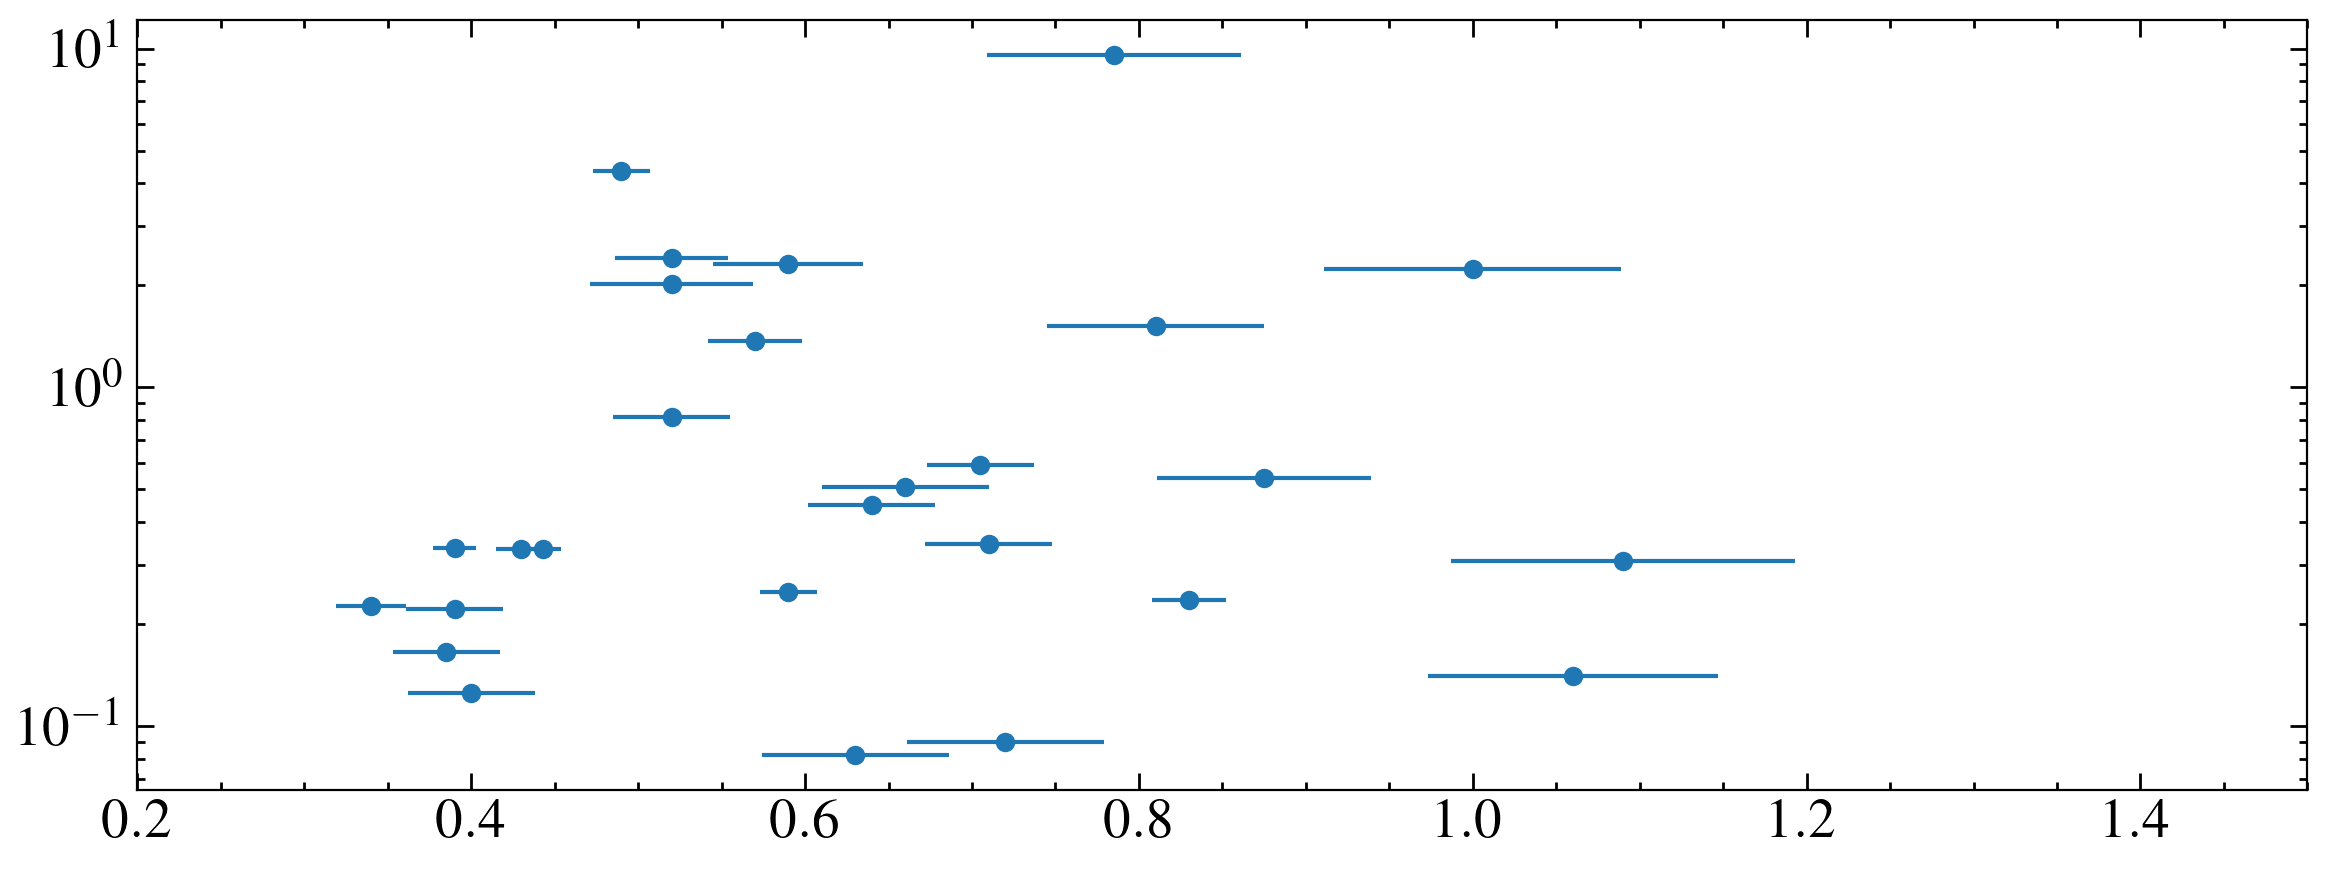

In [29]:
mask = (wdmscat['porb'] > 0) & (wdmscat['Mwd']/wdmscat['Mwde'] > 10) & (wdmscat['M2']/wdmscat['M2e'] > 2)

fig, ax = plt.subplots()

ax.errorbar(wdmscat['Mwd'][mask], wdmscat['porb'][mask]/24, xerr=wdmscat['Mwde'][mask], yerr= wdmscat['porbe'][mask]/24,  ls='none', marker='o')

ax.set_xlim(0.2,  1.5)

ax.set_yscale('log')

In [32]:
longpmask = (wdmscat['porb'] > 24)
longcat = wdmscat[longpmask]
longcat

iau_name,type,Teffwd,Teffwde,logg,logge,Mwd,Mwde,Rwd,Rwde,dwd,dwde,Sp,M2,M2e,R2,R2e,Teffsec,Msec,Msece,Rsec,Rsece,Lsec,Lsece,dsec,dsece,age,sigma,porb,porbe,phot,spec,re,segue,id,iau_name_1,ra,decl,nuv,nuve,fuv,fuve,u,ue,g,ge,r,re_1,i,ie,z,ze,Y,Ye,J,Je,H,He,K,Ke,id_1
str23,str6,int64,int64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int64,int64,int64,int64,int64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
SDSSJ030544.41-074941.2,DA/M,17707,410,7.81,0.095,0.52,0.049,0.01478,0.00088,365,22,4.0,0.319,0.09,0.326,0.096,0,0,0,0,0,0,0,331,97,0,4,48.4612,0.0017,0,1,0,0,220,SDSSJ030544.41-074941.2,46.43504,-7.82811,18.55589,0.04032,18.29016,0.06059,18.6793,0.0223,18.3256,0.0244,18.1216,0.0224,17.3005,0.0186,16.7013,0.0145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,220
SDSSJ092452.39+002449.0,DA/M,19193,335,7.81,0.067,0.52,0.034,0.01484,0.00064,335,15,4.0,0.319,0.09,0.326,0.096,0,0,0,0,0,0,0,514,151,0,4,57.7,0.2,0,1,0,0,587,SDSSJ092452.39+002449.0,141.21829,0.41361,17.67685,0.04271,17.86703,0.03206,18.18022,0.02241,18.03448,0.0156,18.22145,0.01557,17.8679,0.01526,17.40965,0.0226,16.610529,0.010156,16.07432,0.007326,15.57009,0.010629,15.272351,0.014408,587
SDSSJ092741.73+332959.1,DA/M,27111,494,7.91,0.084,0.59,0.045,0.01413,0.0008,505,29,3.0,0.38,0.072,0.391,0.077,0,0,0,0,0,0,0,613,121,0,4,55.3973208,1.6e-06,0,0,0,0,595,SDSSJ092741.73+332959.1,141.92388,33.49975,17.37792,0.02889,0.0,0.0,18.0008,0.0197,18.0658,0.0351,18.227,0.0179,17.764,0.0167,17.2747,0.0155,0.0,0.0,15.974805,0.005976,0.0,0.0,0.0,0.0,595
SDSSJ121130.94-024954.4,DA/M,13130,860,7.84,0.13,0.52,0.07,0.01371,0.0042,356,109,3.0,0.38,0.072,0.391,0.077,0,0,0,0,0,0,0,500,98,0,4,187.632,0.048,0,1,0,0,935,SDSSJ121130.94-024954.4,182.87892,-2.83178,19.72329,0.1038,19.67882,0.14177,19.5862,0.0354,18.9364,0.0197,18.297,0.0168,17.4434,0.0229,16.8641,0.0178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,935
SDSSJ143443.24+533521.2,DA/M,21785,209,7.74,0.037,0.49,0.017,0.01568,0.0004,153,4,4.0,0.319,0.09,0.326,0.096,0,0,0,0,0,0,0,286,84,0,4,104.5622,0.0073,0,1,0,0,1137,SDSSJ143443.24+533521.2,218.68017,53.58922,0.0,0.0,0.0,0.0,15.9206,0.0175,15.942,0.0207,16.2476,0.0124,16.1941,0.0112,15.9265,0.0194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1137
SDSSJ143947.62-010606.7,DA/K:,84455,3902,8.11,0.134,0.81,0.065,0.0132,0.00141,428,46,0.5,0.472,0.078,0.489,0.083,0,0,0,0,0,0,0,826,136,0,4,36.5426,0.0014,0,1,0,0,1152,SDSSJ143947.62-010606.7,219.94842,-1.10192,15.48302,0.0086,14.87211,0.01009,16.1445,0.0142,16.5457,0.0173,16.7586,0.0149,16.7242,0.0132,16.61,0.0207,15.984368,0.006062,15.643733,0.006549,15.143018,0.006924,14.936431,0.010798,1152
SDSSJ151921.72+353625.8,DA/M,19416,246,7.9,0.051,0.57,0.028,0.014,0.00047,165,6,6.0,0.196,0.085,0.195,0.09,0,0,0,0,0,0,0,153,71,0,4,32.81,0.32,0,1,0,0,1196,SDSSJ151921.72+353625.8,229.8405,35.60717,16.45739,0.01772,16.1844,0.02523,16.8481,0.0286,16.7008,0.0163,17.0282,0.0163,17.0387,0.018,16.6683,0.0182,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1196
SDSSJ152821.45+344314.9,DA/M,26801,1022,7.85,0.141,0.56,0.073,0.01472,0.00137,554,51,4.0,0.319,0.09,0.326,0.096,0,0,0,0,0,0,0,449,132,0,4,33.87,0.23,0,1,0,0,1217,SDSSJ152821.45+344314.9,232.08937,34.72081,18.00764,0.03777,17.63196,0.05511,18.4635,0.0214,18.4426,0.0158,18.4603,0.0121,17.8676,0.0142,17.2924,0.0213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1217
SDSSJ164615.60+422349.2,DA/M,17707,516,7.83,0.11,0.53,0.058,0.01459,0.00101,399,27,5.0,0.255,0.124,0.258,0.132,0,0,0,0,0,0,0,300,153,0,4,38.29,0.21,0,1,0,0,1356,SDSSJ164615.60+422349.2,251.565,42.397,18.41335,0.04983,18.17091,0.08824,18.7544,0.0215,18.4283,0.0114,18.5547,0.0158,17.9586,0.0129,17.2227,0.0236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1356


In [65]:
# star = lk.search_lightcurve('TIC219085795')

names, periods, period_es = longcat['iau_name'], longcat['porb'], longcat['porbe']
print(min(periods/24), max(periods/24))

1.3670833333333334 9.588


16.1941 3.01677364140775 d 4.3567583333333335 d 1.4441780694226338
16.7242 1.709198755208062 d 1.5226083333333333 d 0.890831641840264
17.0387 1.3719590525478642 d 1.3670833333333334 d 0.9964461627295099
17.8676 3.4604373755633056 d 1.41125 d 0.407824169847972
17.9586 1.8466453807703336 d 1.5954166666666665 d 0.86395400182418
16.8257 0.9494794638436272 d 1.9029166666666666 d 2.004168324992929
17.9125 3.273031670938225 d 9.588 d 2.929394202058414
17.3778 3.5191381946648495 d 2.2317666666666662 d 0.6341798881470786


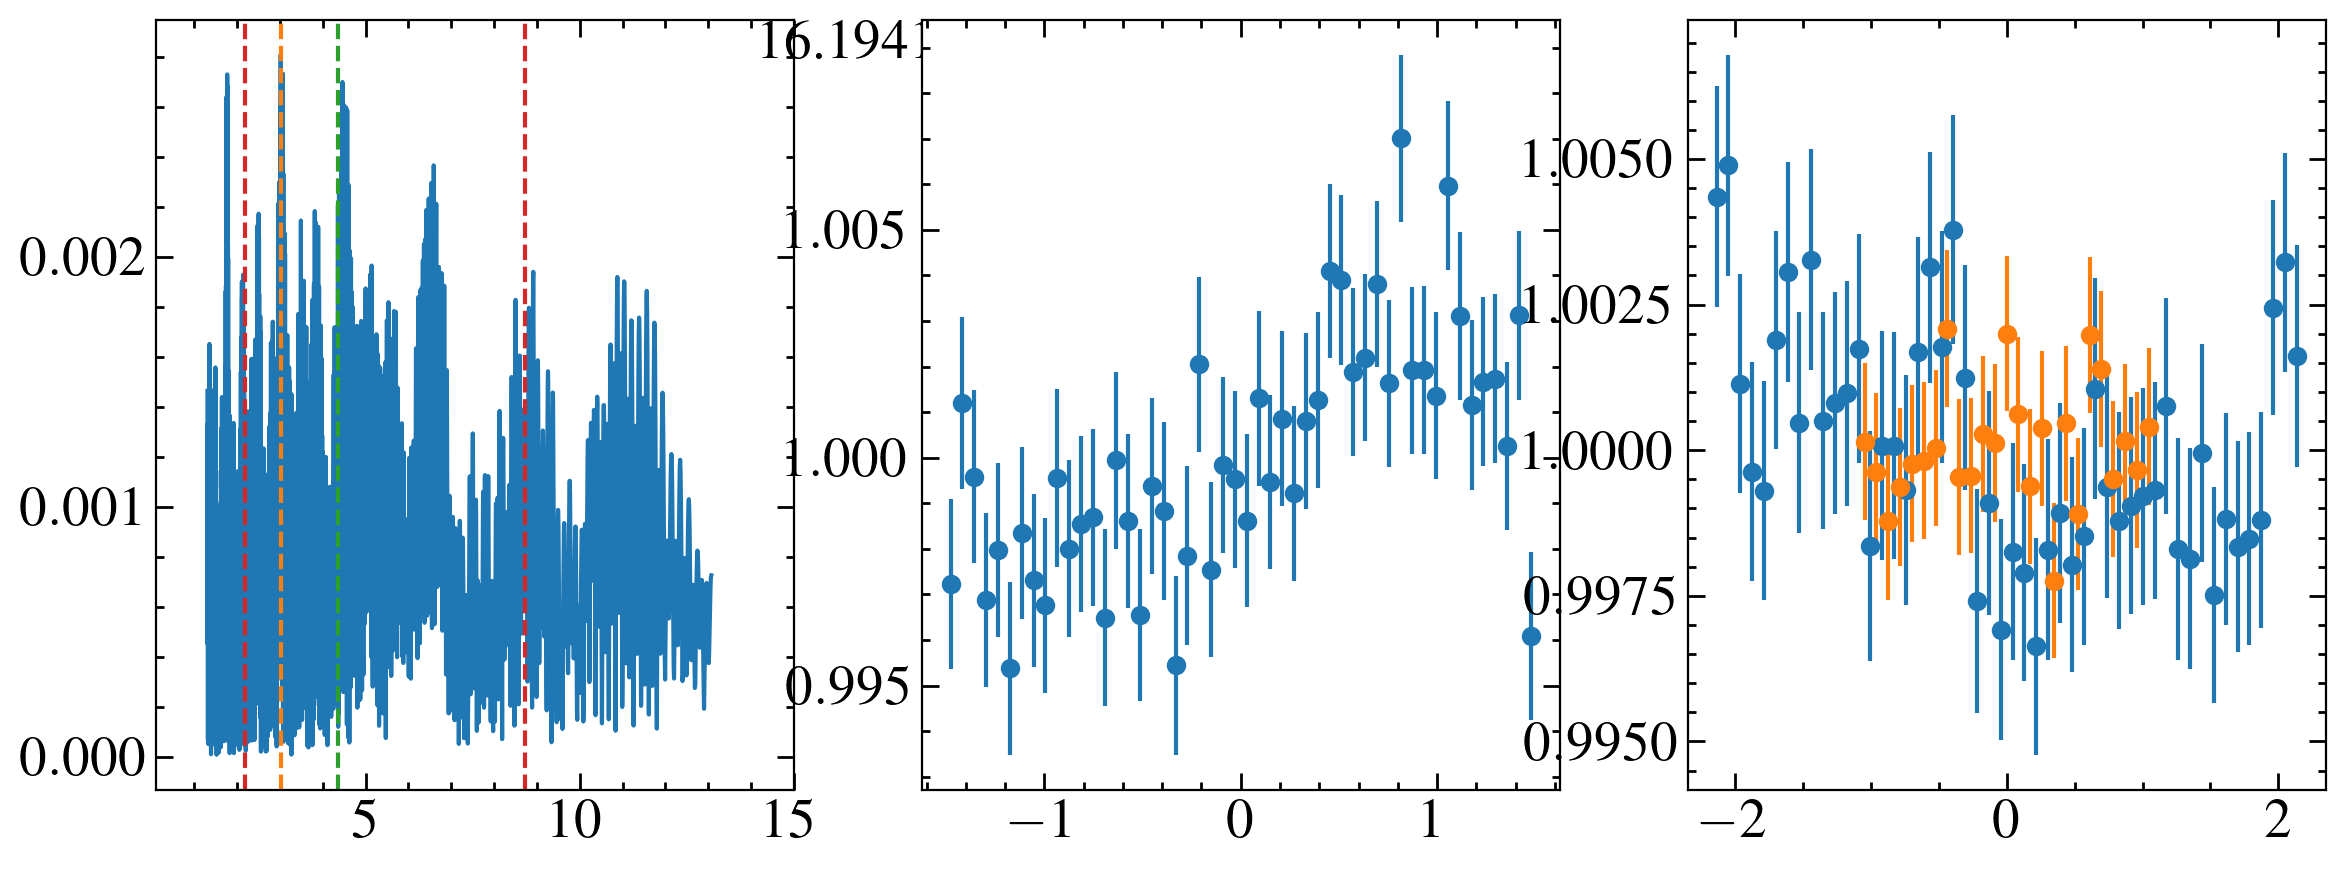

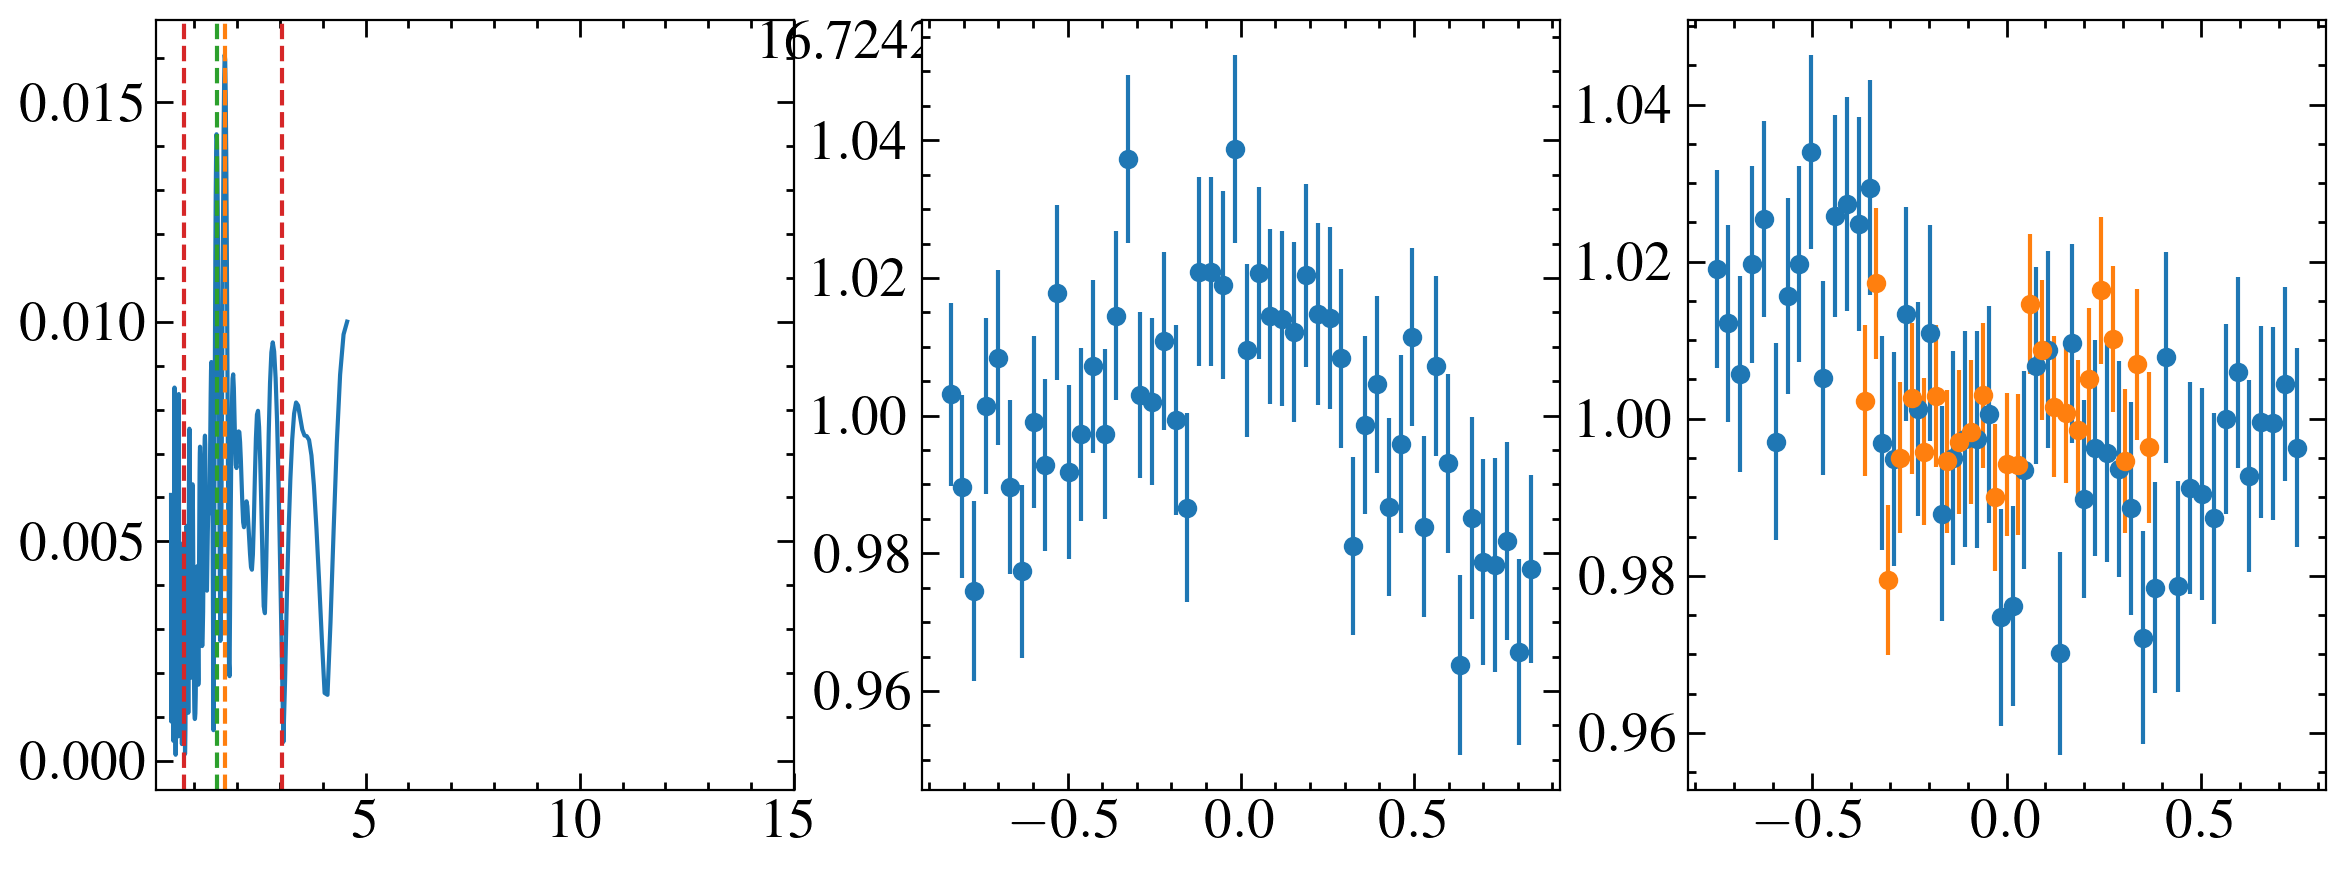

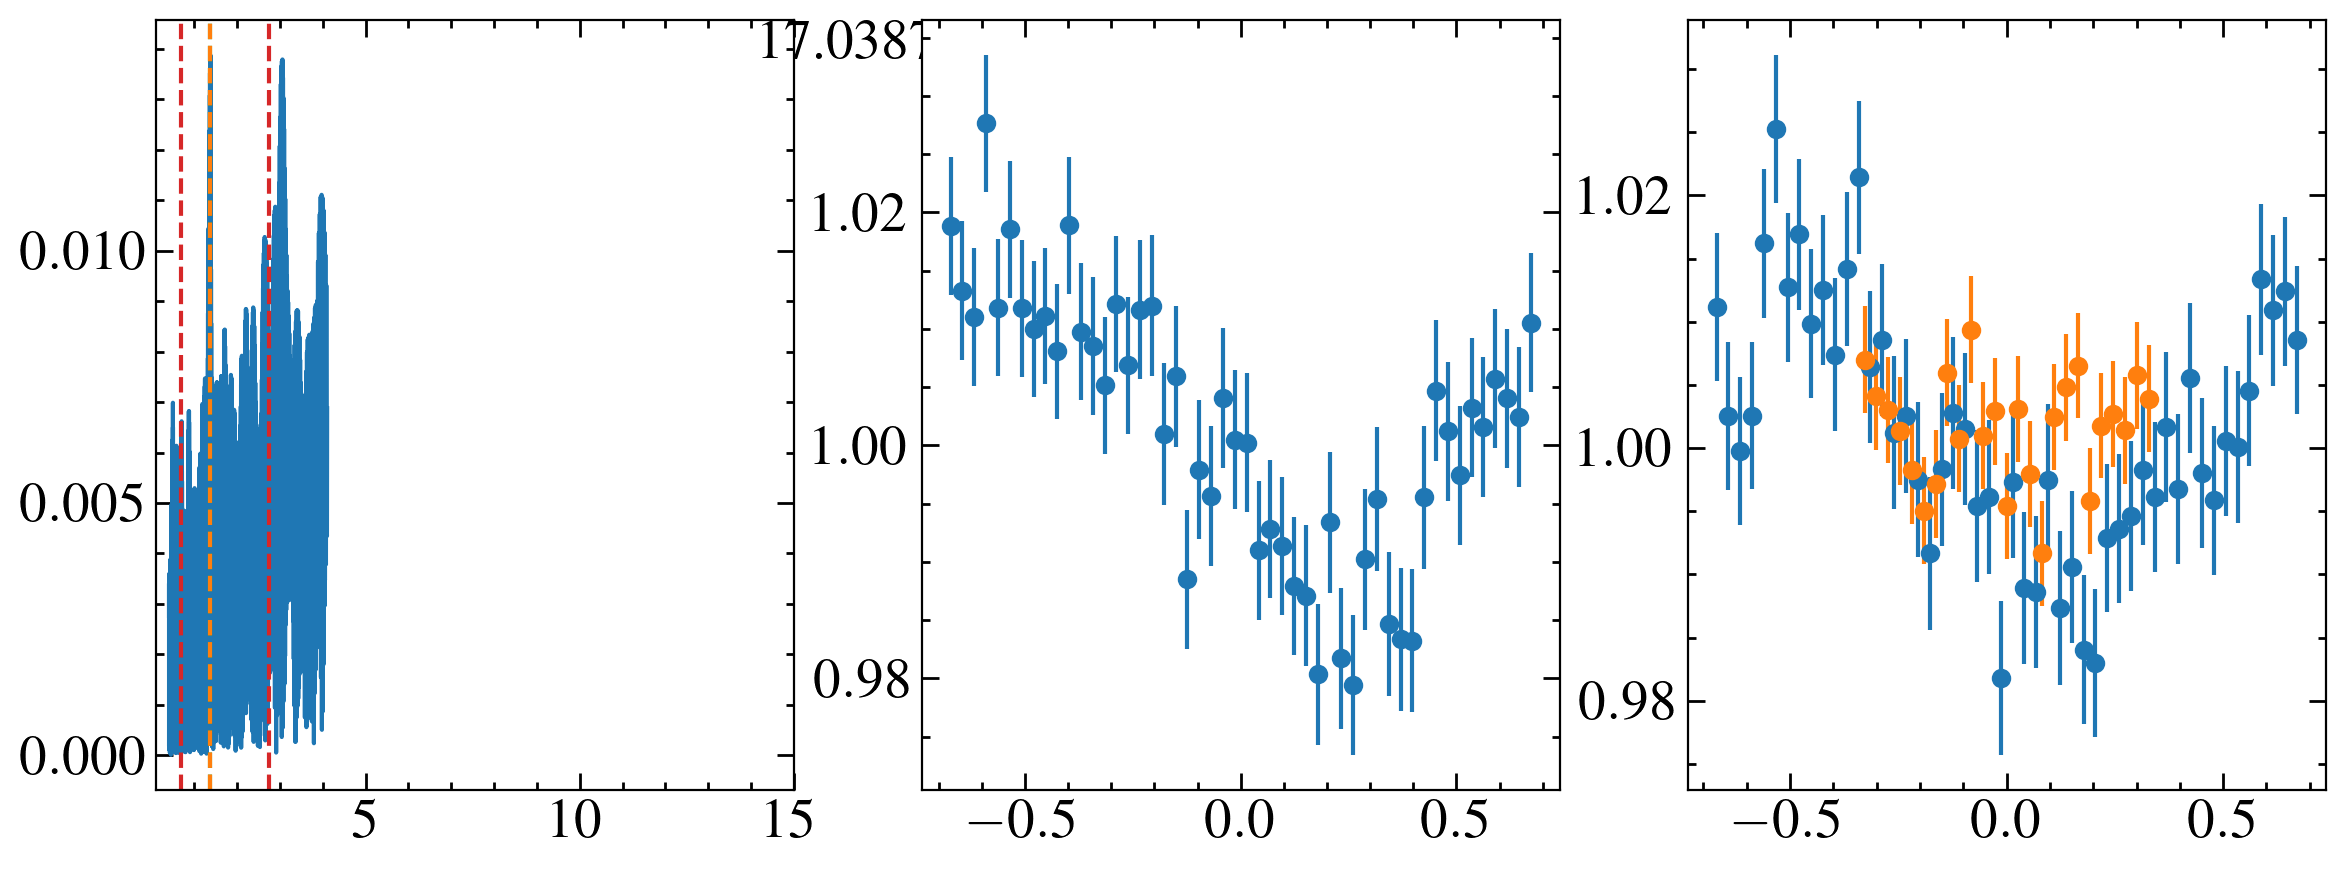

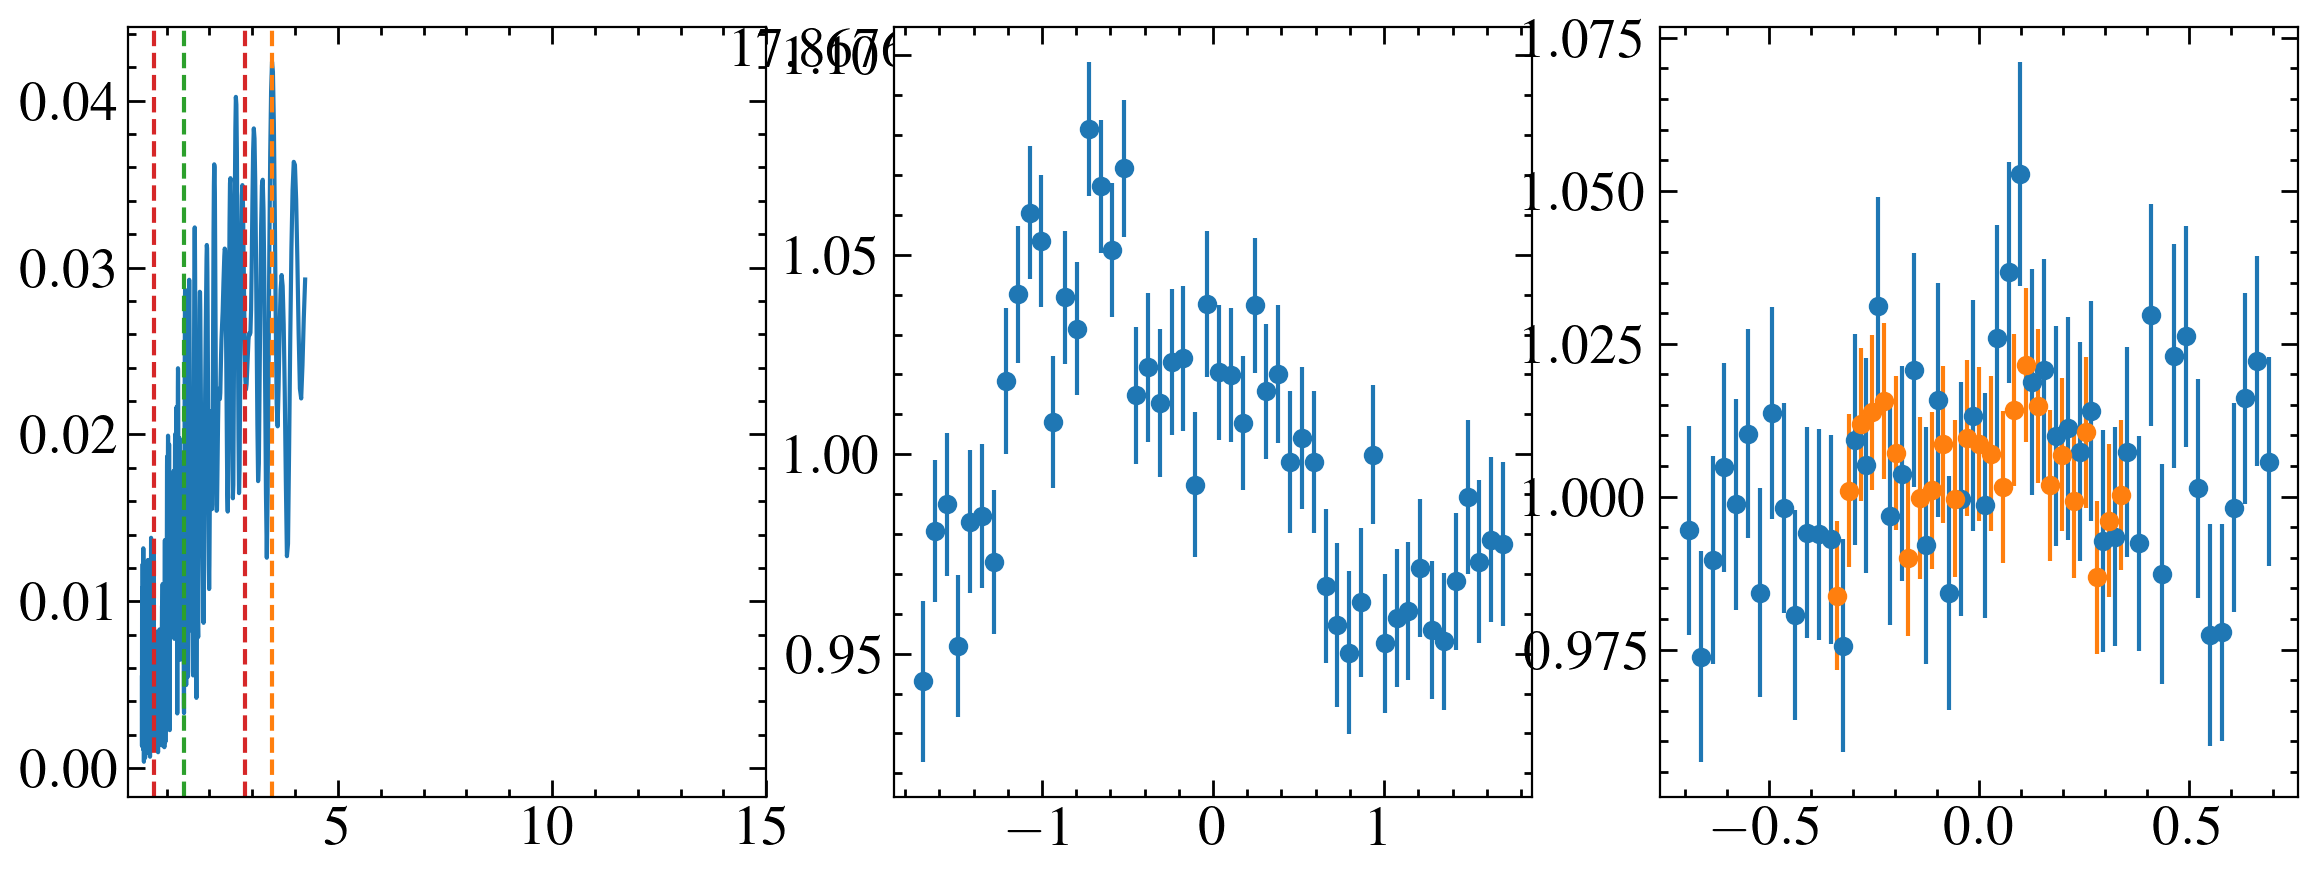

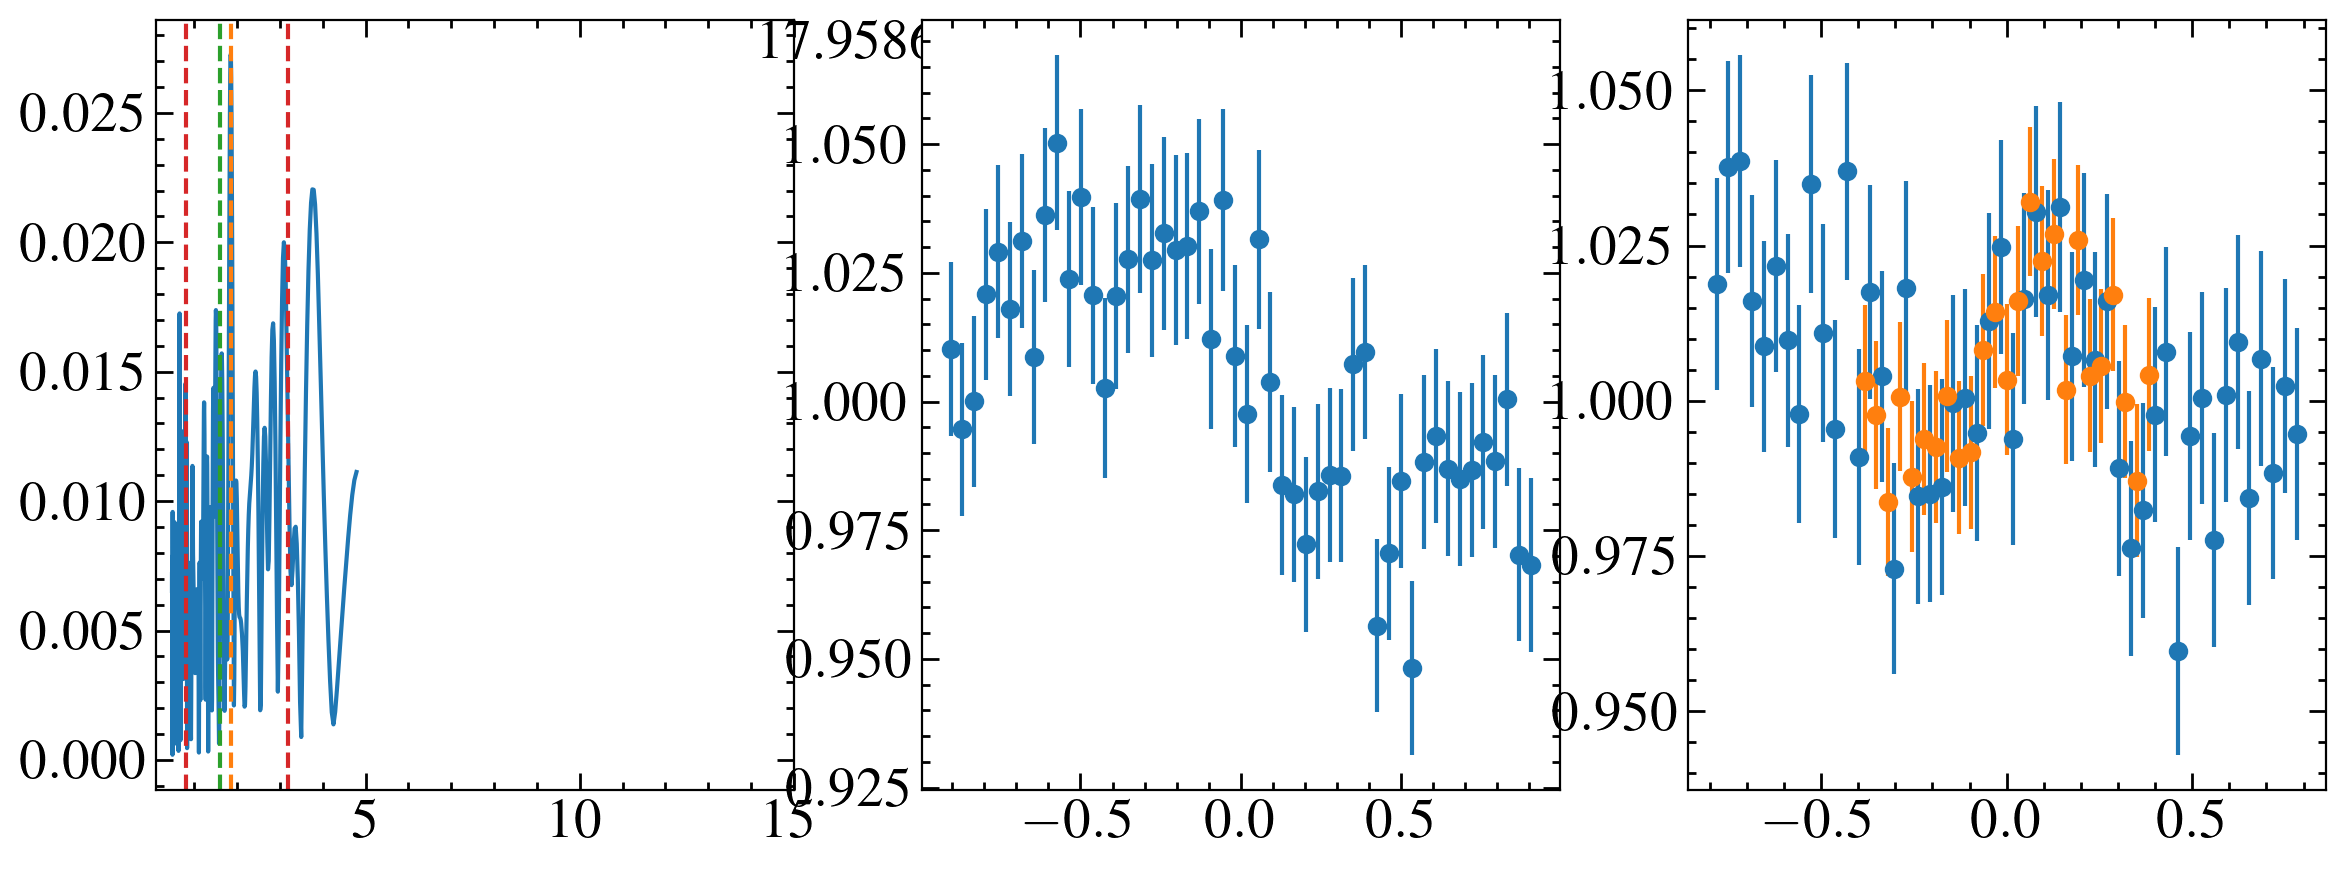

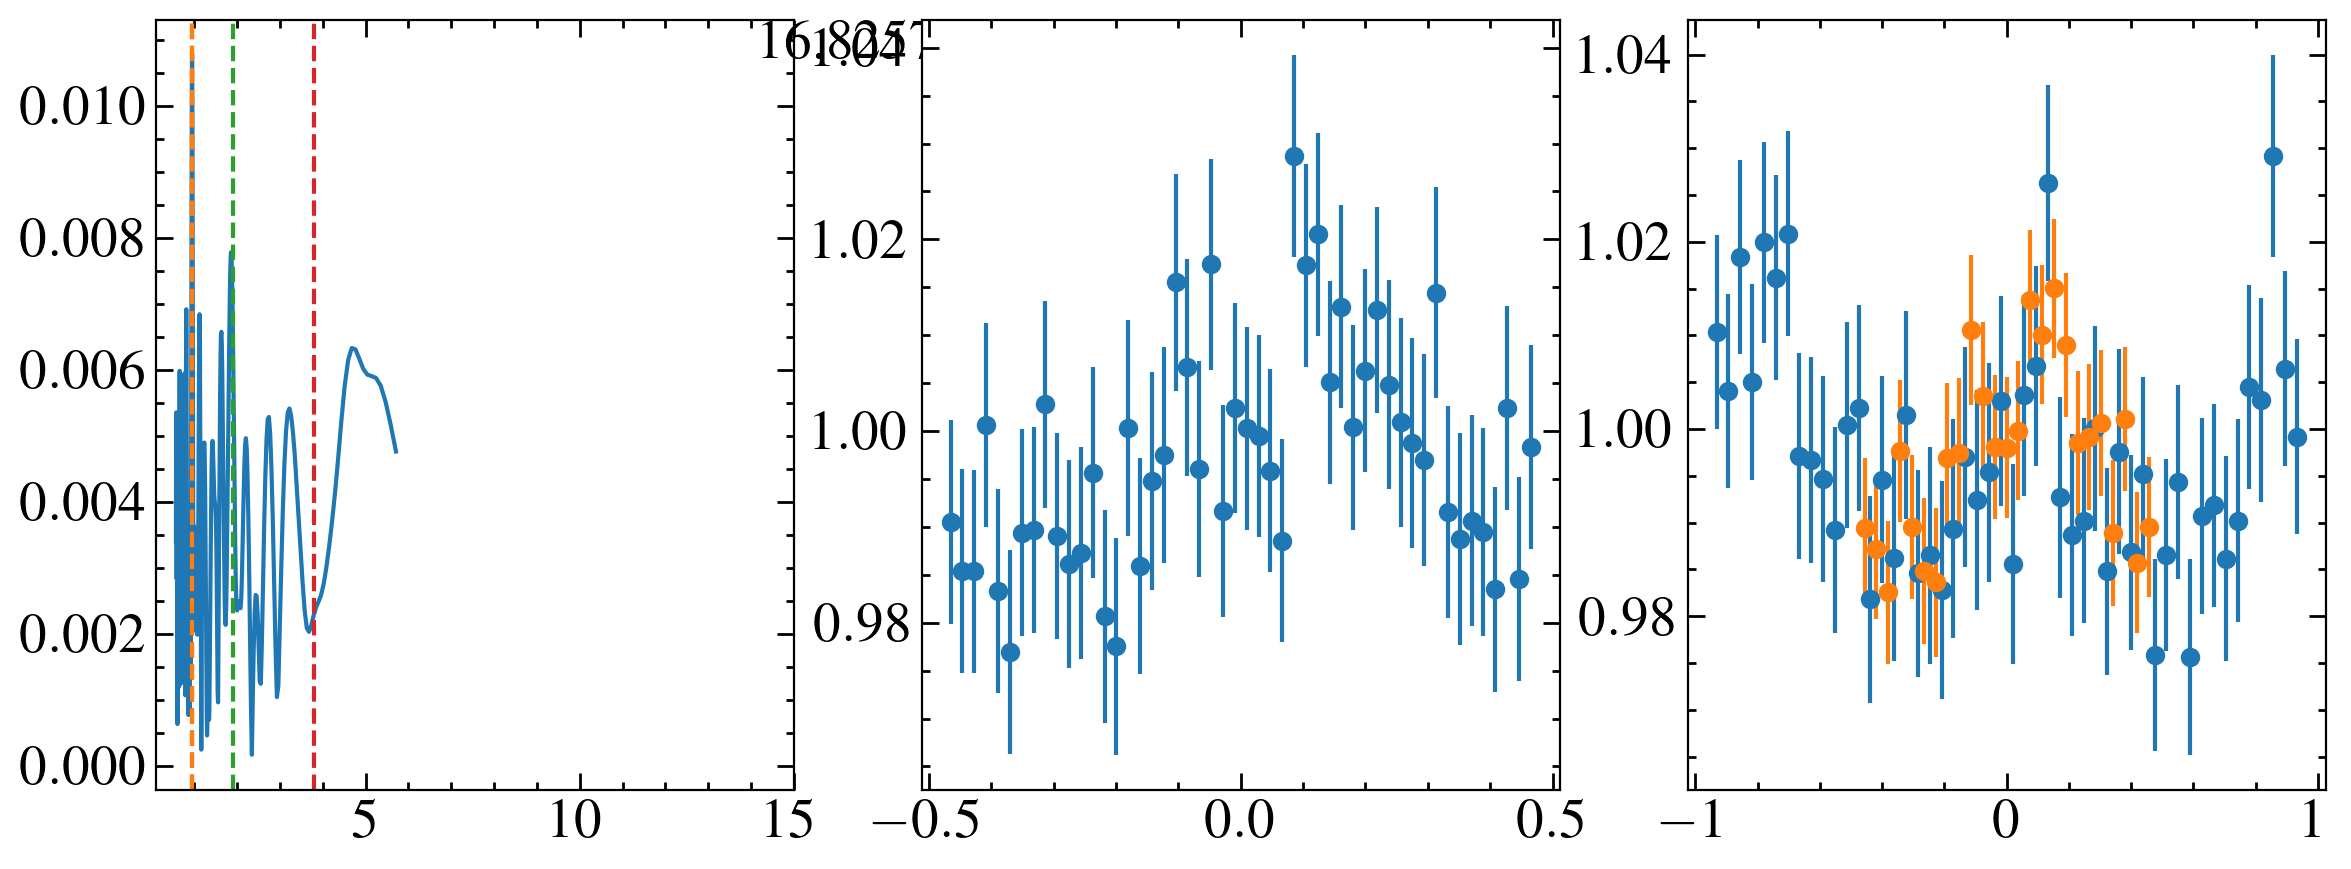

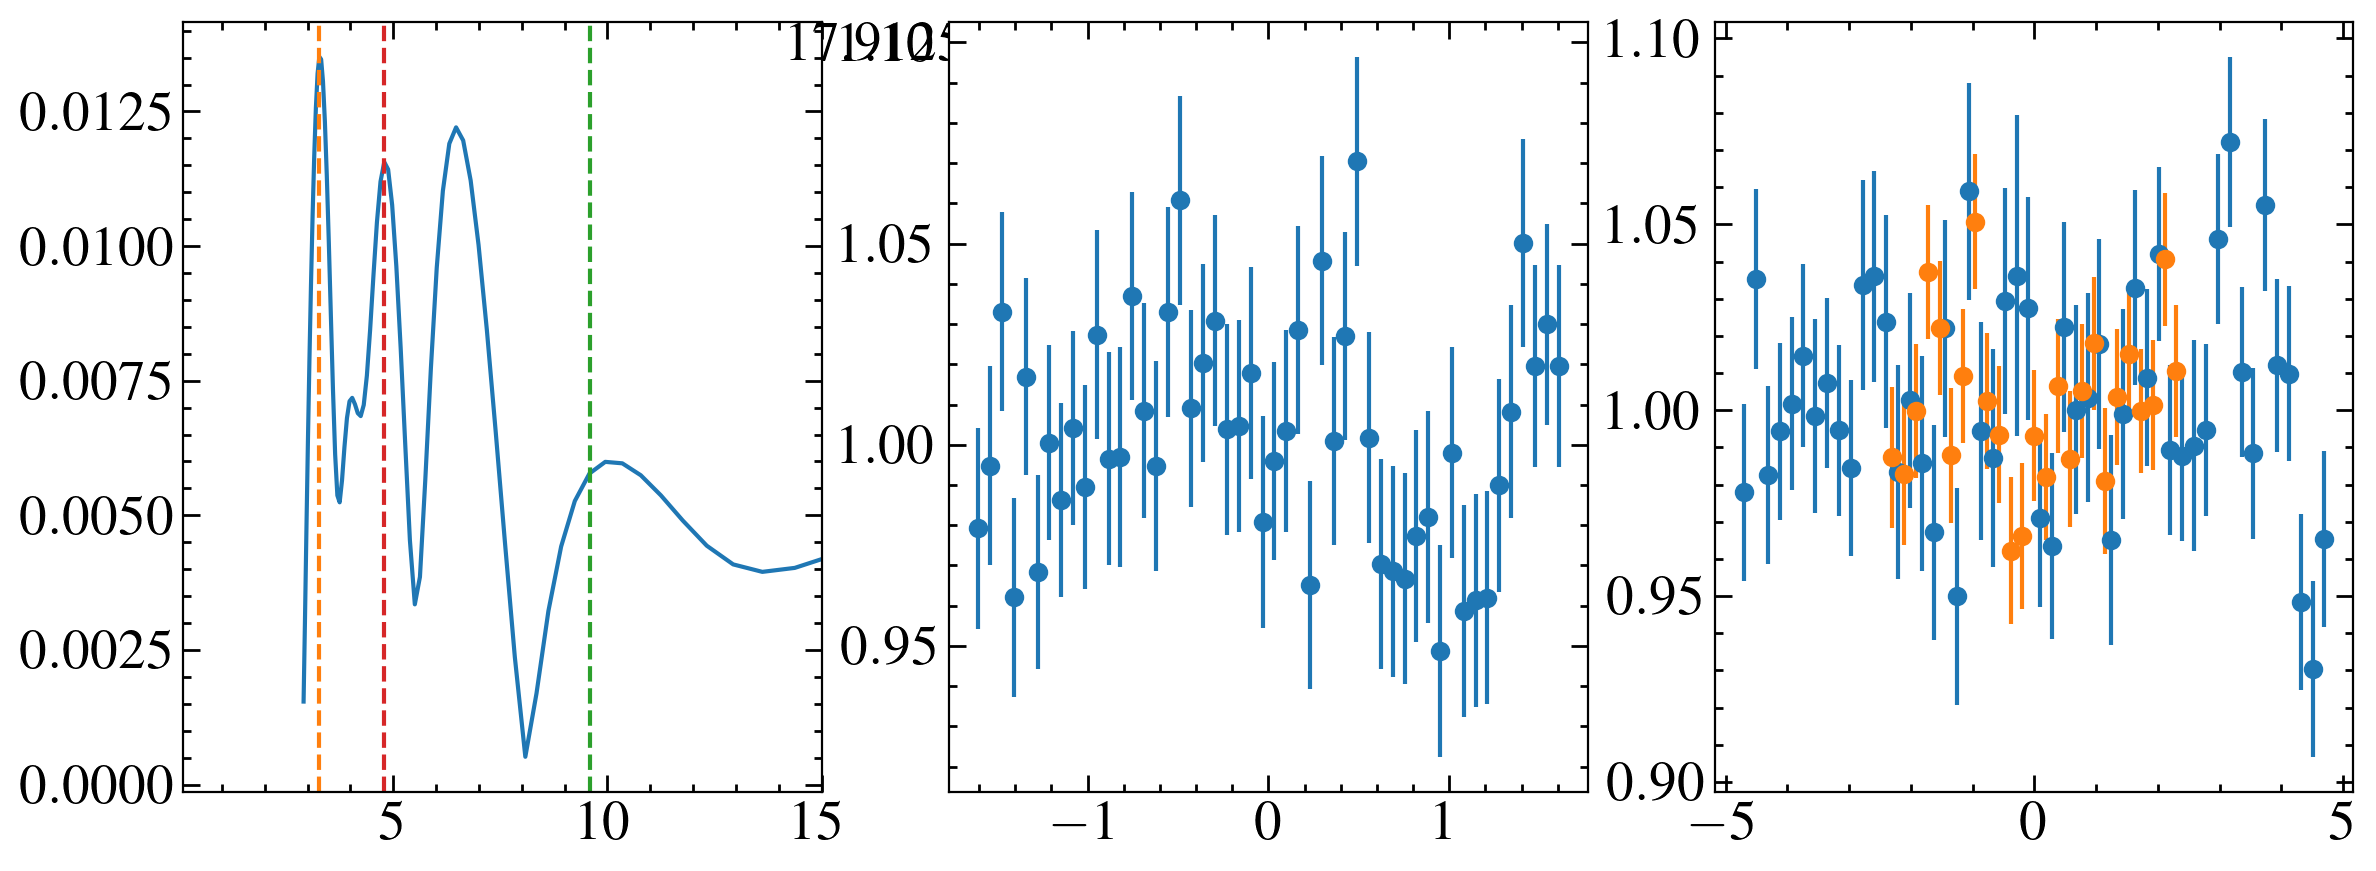

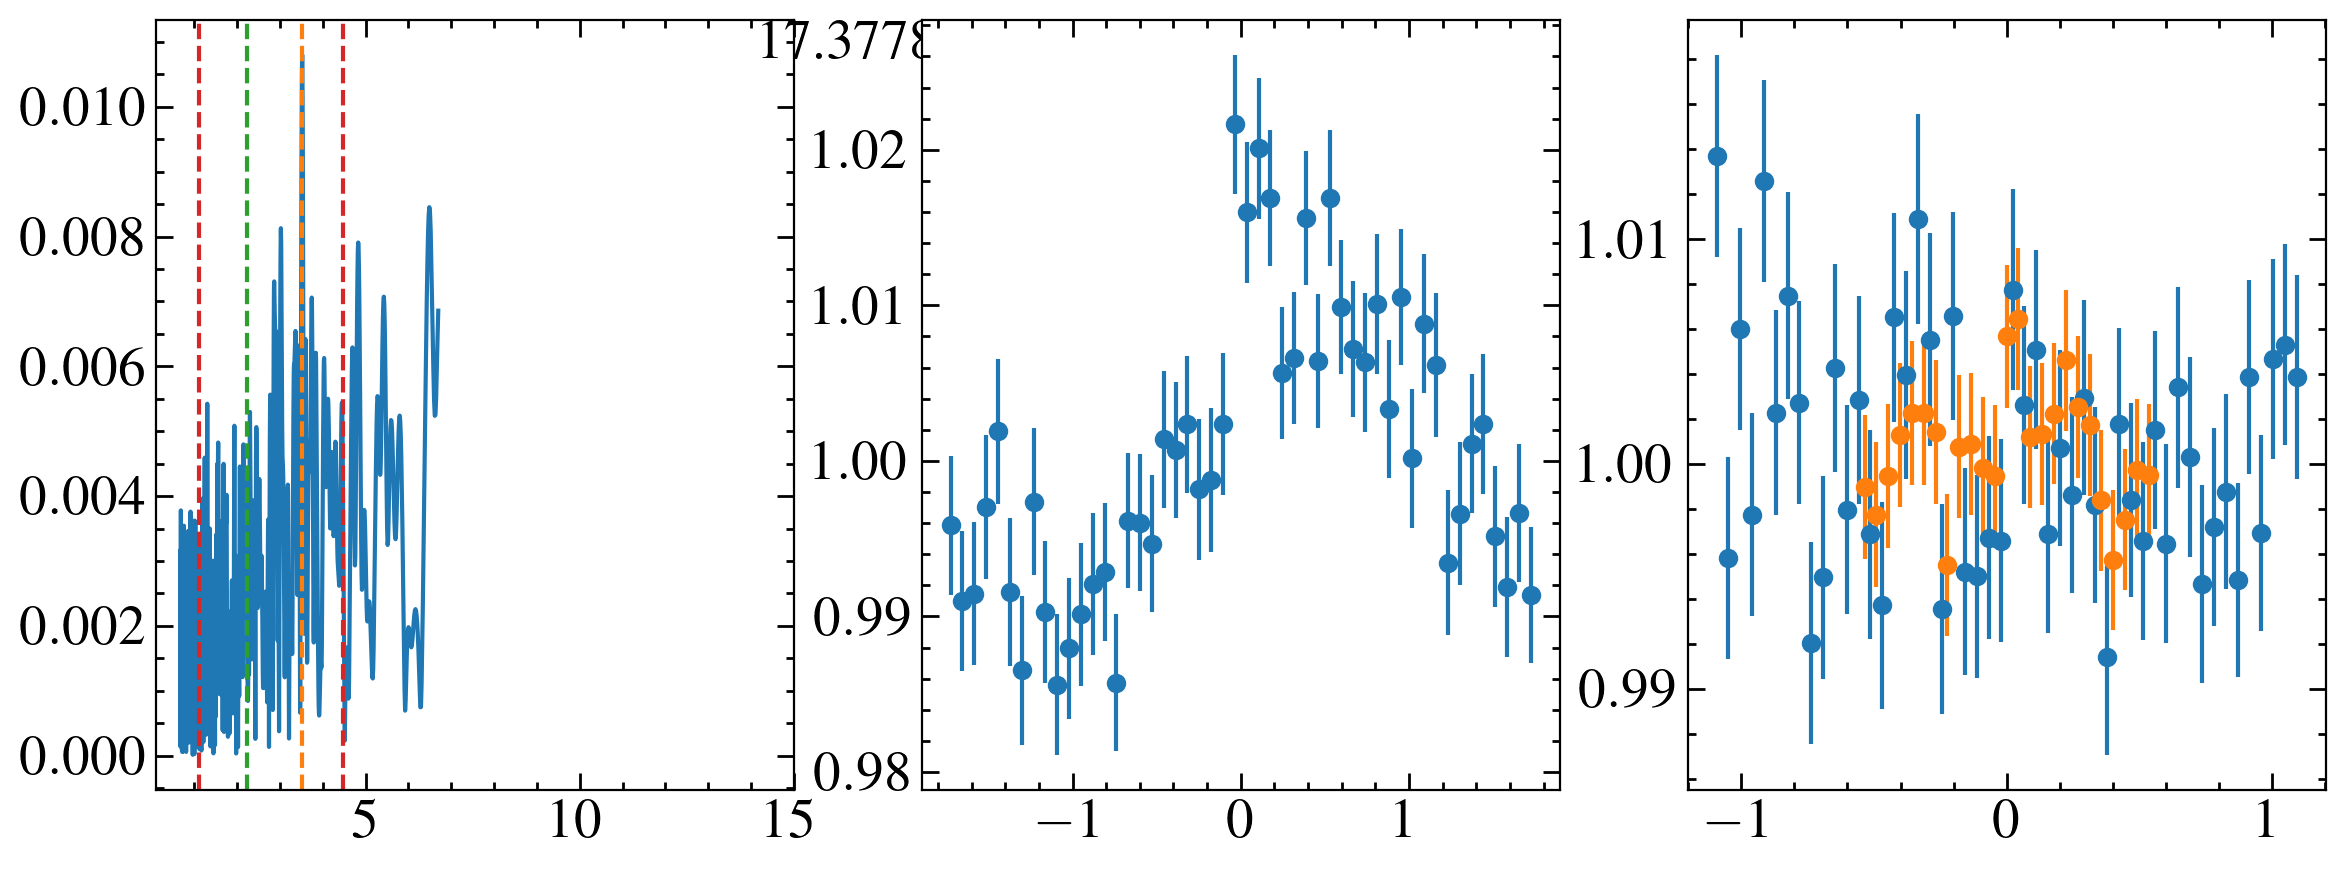

In [90]:
tess_periods = []
porbs = []
porb_es = []


for i, name in enumerate(names):
    porb = (periods[i]*u.hr).to(u.d)

    sr =lk.search_lightcurve(name)
    # print(sr)
    if len(sr) > 0:
        fig, axes = plt.subplots(ncols =3)
        mask = (sr.exptime == 120*u.s) & (sr.author=='SPOC')
        sr = sr[mask]
        # print(sr)
        lcs = sr.download_all(download_dir='data/', quality_bitmask='none')
        lcn = lcs.stitch().remove_outliers().flatten(100001)
        
        # lcn.scatter()
        pg = lcn.to_periodogram(oversample_factor=10,minimum_period=0.3*porb, maximum_period=3*porb)
        period_guess = pg.period_at_max_power
        tess_periods.append(period_guess.value)
        # pg.plot()
        axes[0].plot(pg.period, pg.power)
        axes[0].axvline(porb.value, ls='--', c='C2')
        axes[0].axvline(porb.value/2, ls='--', c='C3')
        axes[0].axvline(porb.value*2, ls='--', c='C3')
        axes[0].axvline(period_guess.value, ls='--', c='C1')
        axes[0].set_xlim(0.1, 15)

        axes[0].annotate(longcat['i'][i], (0.95, 0.95), xycoords='axes fraction')
        print(longcat['i'][i],  period_guess,porb,  porb/period_guess)
        lcf1 = lcn.fold(period_guess).bin(period_guess/50)
        # lcf1.errorbar()
        axes[1].errorbar(lcf1.time.value, lcf1.flux, yerr=lcf1.flux_err, marker='o', ls='none')
        
        lcf2 = lcn.fold(porb).bin(porb/50)
        axes[2].errorbar(lcf2.time.value, lcf2.flux, yerr=lcf2.flux_err, marker='o', ls='none')
        lcf3 = lcn.fold(porb/2).bin(porb/50)
        axes[2].errorbar(lcf3.time.value, lcf3.flux, yerr=lcf3.flux_err, marker='o', ls='none')

        porbs.append(porb.value)
        porb_es.append(period_es[i]/24)
        
        # lcf2.errorbar()
tess_periods = np.array(tess_periods)    
porbs = np.array(porbs)
porb_es = np.array(porb_es)

(0.5, 9.9)

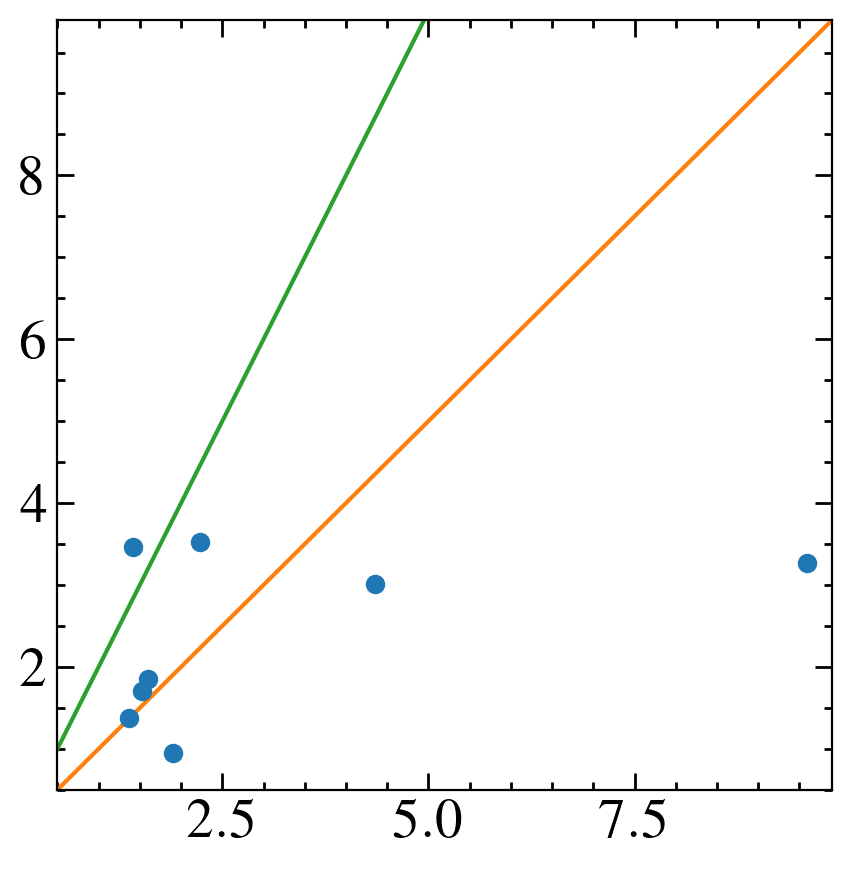

In [82]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(porbs, tess_periods, xerr=porb_es, marker='o', ls='none')

ax.plot([0, 10], [0, 10])
ax.plot([0, 10], [0, 20])

ax.set_xlim(0.5, 9.9)
ax.set_ylim(0.5, 9.9)


In [73]:
tess_periods

array([3.01677364, 1.70919876, 1.37195905, 3.46043738, 1.84664538,
       0.94947946, 3.27303167, 3.51913819])

Have to refine it a bit but no evidence for prot >> porb 

In [85]:
porbs

array([4.35675833, 1.52260833, 1.36708333, 1.41125   , 1.59541667,
       1.90291667, 9.588     , 2.23176667])

Not necesarily the right TIC number, have to look them up individually

In [89]:
max(wdmscat['porb'])

np.float64(230.112)

SDSSJ222108.45+002927.7  = longest period in wdms cat. ZTF?